# DỰ ĐOÁN CHẤT LƯỢNG RƯỢU (WINE QUALITY PREDICTION)

## 1. Tổng quan về Bài toán

Mục tiêu của dự án này là xây dựng một mô hình học máy có khả năng **dự đoán chất lượng rượu vang** dựa trên các đặc trưng hóa học và vật lý của nó.

Để đơn giản hóa và tập trung vào việc phân loại, bài toán ban đầu (dự đoán điểm chất lượng từ 3 đến 9) đã được chuyển đổi thành một bài toán **Phân loại** gồm có cách lass đã được gán nhãn và đã lược bỏ đi quality mức 3 và 9:

**Nhãn 0 - (Quality 4)**
**Nhãn 1 - (Quality 5)**
**Nhãn 2 - (Quality 6)**
**Nhãn 3 - (Quality 7)**
**Nhãn 4 - (Quality 8)**
## 2. Các Đặc trưng Hóa học và Vật lý (Features)

Dữ liệu đầu vào bao gồm 11 thông số quan trọng, đóng vai trò là các đặc trưng (features) để dự đoán chất lượng rượu:

1.  **Fixed Acidity** (Độ axit cố định)
2.  **Volatile Acidity** (Độ axit dễ bay hơi)
3.  **Citric Acid** (Axit citric)
4.  **Residual Sugar** (Lượng đường dư)
5.  **Chlorides** (Clorua)
6.  **Free Sulfur Dioxide** (Lưu huỳnh dioxide tự do)
7.  **Total Sulfur Dioxide** (Tổng lưu huỳnh dioxide)
8.  **Density** (Mật độ)
9.  **pH** (Độ pH)
10. **Sulphates** (Sulphat)
11. **Alcohol** (Độ cồn)

## 3. Các Mô hình Học máy (Models)

Dự án này sử dụng năm mô hình phân loại chính, thuộc thư viện Scikit-learn (Sklearn), để so sánh hiệu suất và tìm ra mô hình tối ưu nhất cho bài toán dự đoán chất lượng rượu:

* **K-Nearest Neighbors Classifier (KNN):** Mô hình phân loại dựa trên khoảng cách.
* **Decision Tree (hay Cây Quyết Định) :** Mô hình cấu trúc phân nhánh giống như sơ đồ cây để minh họa các quyết định và hậu quả tiềm ẩn.
* **Random Forest Classifier:** Mô hình học máy dựa trên tập hợp cây quyết định, giúp giảm thiểu hiện tượng quá khớp (overfitting).
* **Support Vector Machine (SVM) :** Mô hình phân loại mạnh mẽ, tìm kiếm siêu phẳng tối ưu để phân tách các lớp dữ liệu. Việc tinh chỉnh các tham số giúp SVM đạt được hiệu suất tốt nhất.
* **XGBoost :** Một thuật toán cây tăng cường được thiết kế để tối ưu hóa hiệu suất và tốc độ. Nó rất hiệu quả trong việc giải quyết các bài toán phân loại và hồi quy.

## 1. Chuẩn bị môi trường

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)
from imblearn.over_sampling import SMOTE

## 2. Đọc dữ liệu và khảo sát ban đầu

In [ ]:
DATA_PATH = "winequality.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "/content/winequality.csv"

df = pd.read_csv(DATA_PATH)
print("Kích thước dữ liệu gốc: ", df.shape)

df = df[df['quality'].isin([4, 5, 6, 7, 8])]
print("Kích thước dữ liệu sau khi lọc (loại bỏ chất lượng 3 và 9): ", df.shape)

quality_mapping = {4: 0, 5: 1, 6: 2, 7: 3, 8: 4}
df['quality_mapped'] = df['quality'].map(quality_mapping)

display(df.head())
print(f"Kích thước dữ liệu cuối cùng: {df.shape}")
print(f"Số mẫu: {df.shape[0]}, Số cột: {df.shape[1]}")
print("\nPhân bố chất lượng sau khi lọc và gán nhãn:")
print(df['quality_mapped'].value_counts().sort_index())

print("\nKiểu dữ liệu:")
print(df.dtypes)
print("\nThống kê mô tả:")
display(df.describe())

Kích thước dữ liệu gốc:  (4898, 12)
Kích thước dữ liệu sau khi lọc (loại bỏ chất lượng 3 và 9):  (4873, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_mapped
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,2
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,2
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,2
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,2
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,2


Kích thước dữ liệu cuối cùng: (4873, 13)
Số mẫu: 4873, Số cột: 13

Phân bố chất lượng sau khi lọc và gán nhãn:
quality_mapped
0     163
1    1457
2    2198
3     880
4     175
Name: count, dtype: int64

Kiểu dữ liệu:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
quality_mapped            int64
dtype: object

Thống kê mô tả:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_mapped
count,4865.000000,4866.000000,4871.000000,4871.000000,4871.000000,4873.000000,4873.000000,4873.000000,4866.000000,4871.000000,4873.000000,4873.000000,4873.000000
mean,6.851891,0.278006,0.334190,6.395586,0.045762,35.236097,138.251283,0.994026,3.188083,0.489922,10.513253,5.886518,1.886518
std,0.837040,0.100609,0.121154,5.072752,0.021697,16.445156,42.011360,0.002990,0.150765,0.114157,1.229856,0.862730,0.862730
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,4.000000,0.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991730,3.090000,0.410000,9.500000,5.000000,1.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000,2.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000,2.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,138.500000,344.000000,1.038980,3.820000,1.080000,14.200000,8.000000,4.000000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##3. Phân bố chất lượng rượu (Quality)

Phân bố nhãn chất lượng rượu:
quality_mapped
0     163
1    1457
2    2198
3     880
4     175
Name: count, dtype: int64

Nhận xét: Dữ liệu tập trung, có sự mất cân bằng nhẹ.


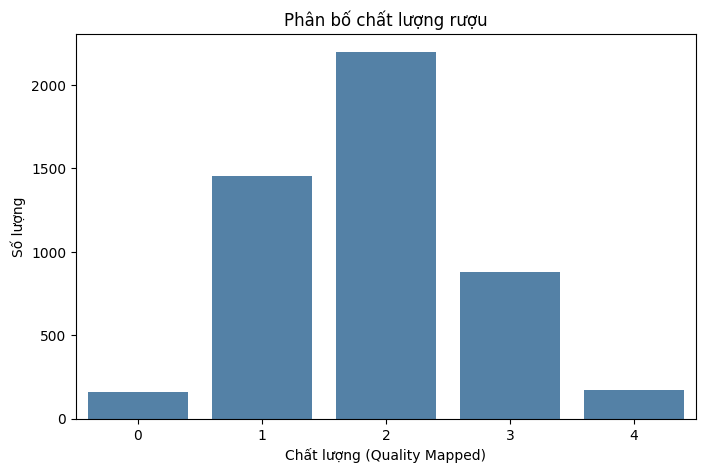

In [ ]:
print("Phân bố nhãn chất lượng rượu:")
quality_counts = df['quality_mapped'].value_counts().sort_index()
print(quality_counts)
print(f"\nNhận xét: Dữ liệu tập trung, có sự mất cân bằng nhẹ.")

plt.figure(figsize=(8, 5))
sns.barplot(x=quality_counts.index, y=quality_counts.values, color='steelblue')
plt.title('Phân bố chất lượng rượu')
plt.xlabel('Chất lượng (Quality Mapped)')
plt.ylabel('Số lượng')
plt.show()

## 4. Tiền xử lý dữ liệu (Data Preprocessing)

### 4.1 Thống kê và xử lý dữ liệu thiếu

In [ ]:
print("Kiểm tra giá trị thiếu:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("\n✓ Tuyệt vời! Dữ liệu không có giá trị thiếu.")
else:
    print("\n⚠ Phát hiện giá trị thiếu, tiến hành xử lý...")
    df.fillna(df.median(), inplace=True)
    print("✓ Đã xử lý giá trị thiếu bằng giá trị median.")

Kiểm tra giá trị thiếu:
fixed acidity       8
volatile acidity    7
citric acid         2
residual sugar      2
chlorides           2
pH                  7
sulphates           2
dtype: int64

⚠ Phát hiện giá trị thiếu, tiến hành xử lý...
✓ Đã xử lý giá trị thiếu bằng giá trị median.


### 4.2 Chia tập Train/Test
**Lý do chọn `test_size=0.2` (80/20):**
- Đảm bảo tập train đủ lớn để mô hình học tốt (80%).
- Tập test đủ lớn để đánh giá đáng tin cậy (20%).
- Tỷ lệ 80/20 là chuẩn phổ biến trong Machine Learning.

In [ ]:
X = df.drop(['quality', 'quality_mapped'], axis=1)
y = df['quality_mapped']

print(f"\n📊 Thông tin dữ liệu:")
print(f"   • Số features: {X.shape[1]}")
print(f"   • Số mẫu: {X.shape[0]}")

print(f"\n📝 Danh sách features ({len(X.columns)} cột):")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain set: {X_train.shape[0]} mẫu ({X_train.shape[0]/len(X)*100:.1f}%) -- Phân bố y_train:\n{y_train.value_counts().sort_index()}")
print(f"Test set:  {X_test.shape[0]} mẫu ({X_test.shape[0]/len(X)*100:.1f}%) -- Phân bố y_test:\n{y_test.value_counts().sort_index()}")


📊 Thông tin dữ liệu:
   • Số features: 11
   • Số mẫu: 4873

📝 Danh sách features (11 cột):
    1. fixed acidity
    2. volatile acidity
    3. citric acid
    4. residual sugar
    5. chlorides
    6. free sulfur dioxide
    7. total sulfur dioxide
    8. density
    9. pH
   10. sulphates
   11. alcohol

Train set: 3898 mẫu (80.0%) -- Phân bố y_train:
quality_mapped
0     130
1    1166
2    1758
3     704
4     140
Name: count, dtype: int64
Test set:  975 mẫu (20.0%) -- Phân bố y_test:
quality_mapped
0     33
1    291
2    440
3    176
4     35
Name: count, dtype: int64


### 4.3 Kiểm tra outlier

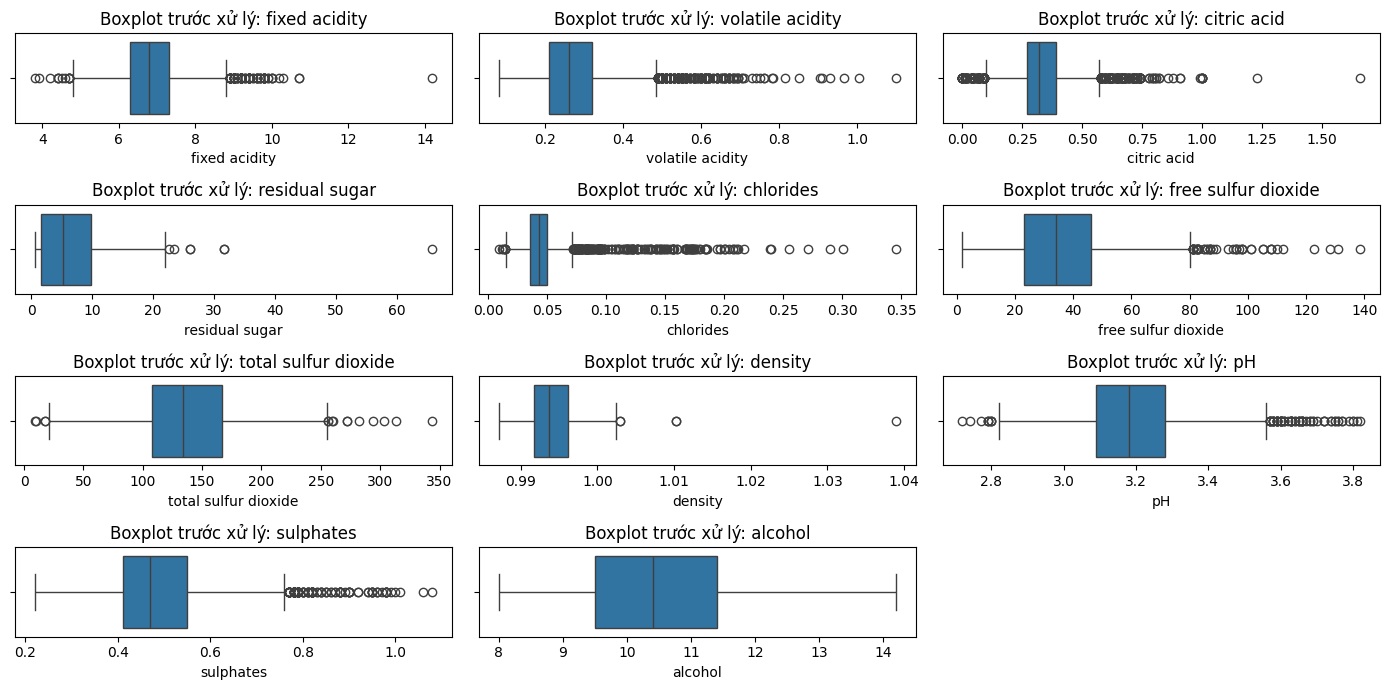

In [ ]:
plt.figure(figsize=(14, 7))
num_cols = len(X.columns)
rows = (num_cols + 2) // 3
for i, col in enumerate(X.columns):
    plt.subplot(rows, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot trước xử lý: {col}")
plt.tight_layout()
plt.show()


### 4.4 Xử lí outlier

Số lượng ngoại lai trong X_train trước clipping:


,feature,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers
0,fixed acidity,6.30000,7.3000,1.00000,4.8000,8.80000,91
1,volatile acidity,0.21000,0.3200,0.11000,0.0450,0.48500,144
2,citric acid,0.27000,0.3900,0.12000,0.0900,0.57000,227
3,residual sugar,1.70000,10.0000,8.30000,-10.7500,22.45000,6
4,chlorides,0.03600,0.0500,0.01400,0.0150,0.07100,165
5,free sulfur dioxide,23.00000,46.0000,23.00000,-11.5000,80.50000,38
6,total sulfur dioxide,109.00000,168.0000,59.00000,20.5000,256.50000,9
7,density,0.99176,0.9962,0.00444,0.9851,1.00286,4
8,pH,3.08000,3.2800,0.20000,2.7800,3.58000,57
9,sulphates,0.41000,0.5500,0.14000,0.2000,0.76000,93


Số lượng ngoại lai trong X_train sau clipping:


,feature,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers
0,fixed acidity,6.30000,7.3000,1.00000,4.8000,8.80000,0
1,volatile acidity,0.21000,0.3200,0.11000,0.0450,0.48500,0
2,citric acid,0.27000,0.3900,0.12000,0.0900,0.57000,0
3,residual sugar,1.70000,10.0000,8.30000,-10.7500,22.45000,0
4,chlorides,0.03600,0.0500,0.01400,0.0150,0.07100,0
5,free sulfur dioxide,23.00000,46.0000,23.00000,-11.5000,80.50000,0
6,total sulfur dioxide,109.00000,168.0000,59.00000,20.5000,256.50000,0
7,density,0.99176,0.9962,0.00444,0.9851,1.00286,0
8,pH,3.08000,3.2800,0.20000,2.7800,3.58000,0
9,sulphates,0.41000,0.5500,0.14000,0.2000,0.76000,0


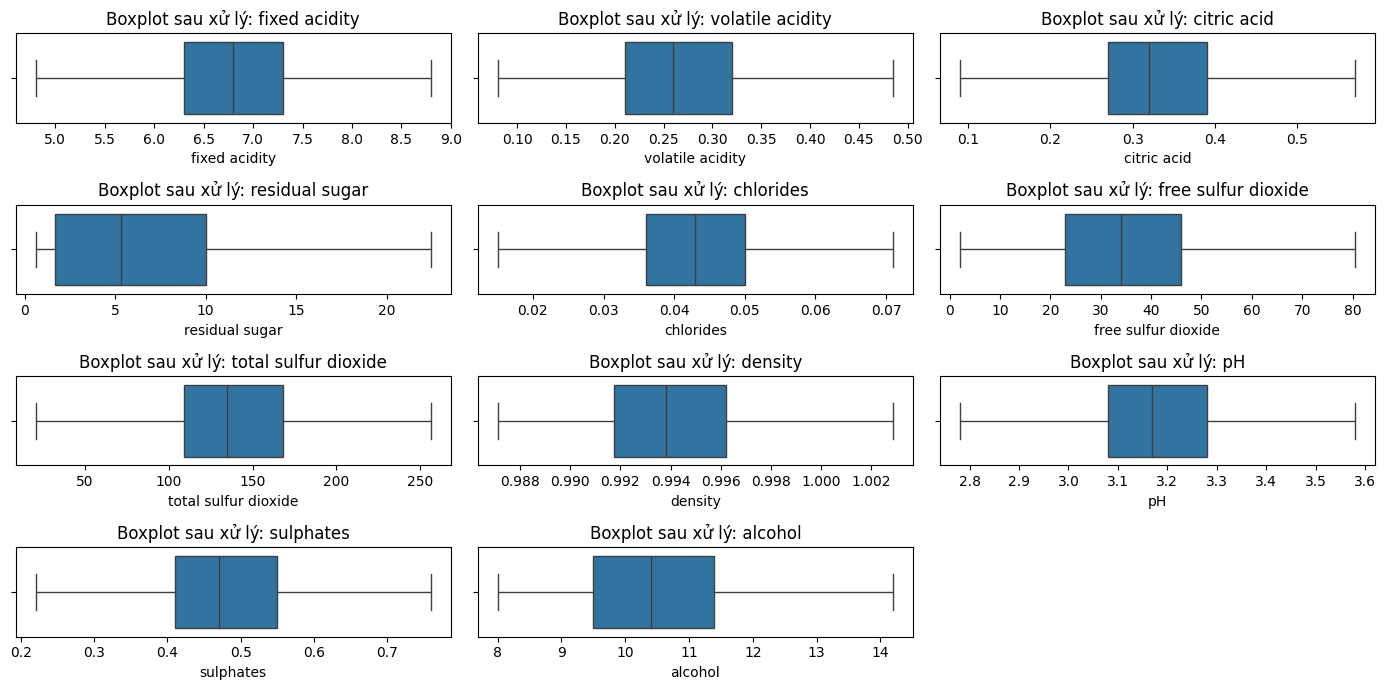

✓ Đã xử lý outlier và cập nhật X_train, X_test
  Số mẫu train: 3898, Số mẫu test: 975

📊 So sánh trước và sau khi xử lý outlier:

fixed acidity:
  Trước: min=3.80, max=14.20
  Sau:   min=4.80, max=8.80

volatile acidity:
  Trước: min=0.08, max=1.10
  Sau:   min=0.08, max=0.49

citric acid:
  Trước: min=0.00, max=1.66
  Sau:   min=0.09, max=0.57

residual sugar:
  Trước: min=0.60, max=65.80
  Sau:   min=0.60, max=22.45

chlorides:
  Trước: min=0.01, max=0.35
  Sau:   min=0.01, max=0.07


In [ ]:
def count_outliers_iqr(data, columns):
    rows = []
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append({
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "n_outliers": n_outliers
        })
    return pd.DataFrame(rows)

def get_iqr_bounds_from_train(data, columns):
    bounds = {}
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        bounds[col] = (lower, upper)
    return bounds

def apply_iqr_clipping_to_data(data, bounds):
    data_clipped = data.copy()
    for col, (lower, upper) in bounds.items():
        data_clipped[col] = data_clipped[col].clip(lower=lower, upper=upper)
    return data_clipped

numeric_cols = X_train.columns

outlier_summary_before = count_outliers_iqr(X_train, numeric_cols)
print("Số lượng ngoại lai trong X_train trước clipping:")
display(outlier_summary_before)

bounds = get_iqr_bounds_from_train(X_train, numeric_cols)

X_train_clipped = apply_iqr_clipping_to_data(X_train, bounds)
X_test_clipped = apply_iqr_clipping_to_data(X_test, bounds)

X_train = X_train_clipped
X_test = X_test_clipped

outlier_summary_after = count_outliers_iqr(X_train, numeric_cols)
print("Số lượng ngoại lai trong X_train sau clipping:")
display(outlier_summary_after)

plt.figure(figsize=(14, 7))
num_cols = len(numeric_cols)
rows = (num_cols + 2) // 3

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, 3, i)
    sns.boxplot(x=X_train[col])
    plt.title(f"Boxplot sau xử lý: {col}")
plt.tight_layout()
plt.show()

print("✓ Đã xử lý outlier và cập nhật X_train, X_test")
print(f"  Số mẫu train: {X_train.shape[0]}, Số mẫu test: {X_test.shape[0]}")

print("\n📊 So sánh trước và sau khi xử lý outlier:")
print("=" * 60)
for col in X_train.columns[:5]:
    original_min = df[col].min()
    original_max = df[col].max()
    capped_min = X_train[col].min()
    capped_max = X_train[col].max()
    print(f"\n{col}:")
    print(f"  Trước: min={original_min:.2f}, max={original_max:.2f}")
    print(f"  Sau:   min={capped_min:.2f}, max={capped_max:.2f}")

### 4.5 Chuẩn hóa dữ liệu (Standardization)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
print("\n--- Trước khi SMOTE ---")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print("\n--- Sau khi SMOTE (Dữ liệu Train đã cân bằng) ---")
print(y_train_resampled.value_counts())


--- Trước khi SMOTE ---
quality_mapped
2    1758
1    1166
3     704
4     140
0     130
Name: count, dtype: int64

--- Sau khi SMOTE (Dữ liệu Train đã cân bằng) ---
quality_mapped
1    1758
3    1758
2    1758
0    1758
4    1758
Name: count, dtype: int64


## 5. Khám phá dữ liệu (Exploratory Data Analysis - EDA)

### 5.1 Ma trận tương quan (Correlation Heatmap)
Xem yếu tố nào ảnh hưởng mạnh đến Quality.

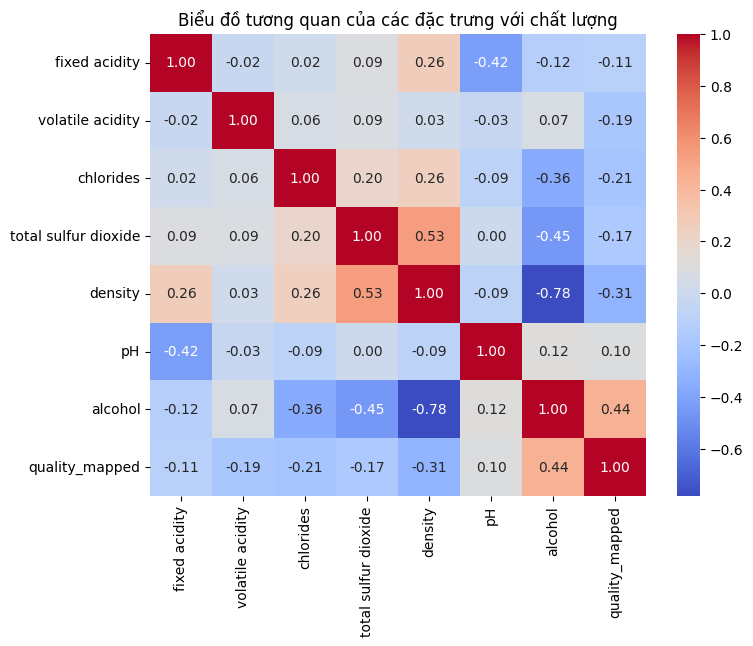

Tương quan của từng đặc trưng với chất lượng:


,corr_with_quality_mapped
alcohol,0.442808
density,-0.309837
chlorides,-0.209711
volatile acidity,-0.194723
total sulfur dioxide,-0.169875
fixed acidity,-0.108751
pH,0.099098


Đặc trưng được chọn : ['alcohol', 'density', 'chlorides', 'volatile acidity', 'total sulfur dioxide']


In [ ]:
features_to_exclude_from_corr_matrix = ['citric acid','free sulfur dioxide','sulphates','residual sugar']
feature_candidates = [col for col in X.columns if col not in features_to_exclude_from_corr_matrix]

ma_tran_tuong_quan = df[feature_candidates + ["quality_mapped"]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(ma_tran_tuong_quan, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Biểu đồ tương quan của các đặc trưng với chất lượng")
plt.show()

corr_with_target = ma_tran_tuong_quan["quality_mapped"].drop("quality_mapped")
corr_with_target = corr_with_target.sort_values(key=lambda s: s.abs(), ascending=False)
print("Tương quan của từng đặc trưng với chất lượng:")
display(corr_with_target.to_frame("corr_with_quality_mapped"))

selected_features = corr_with_target.head(5).index.tolist()
print("Đặc trưng được chọn :", selected_features)

### 5.2 Histogram - Phân phối từng thuộc tính

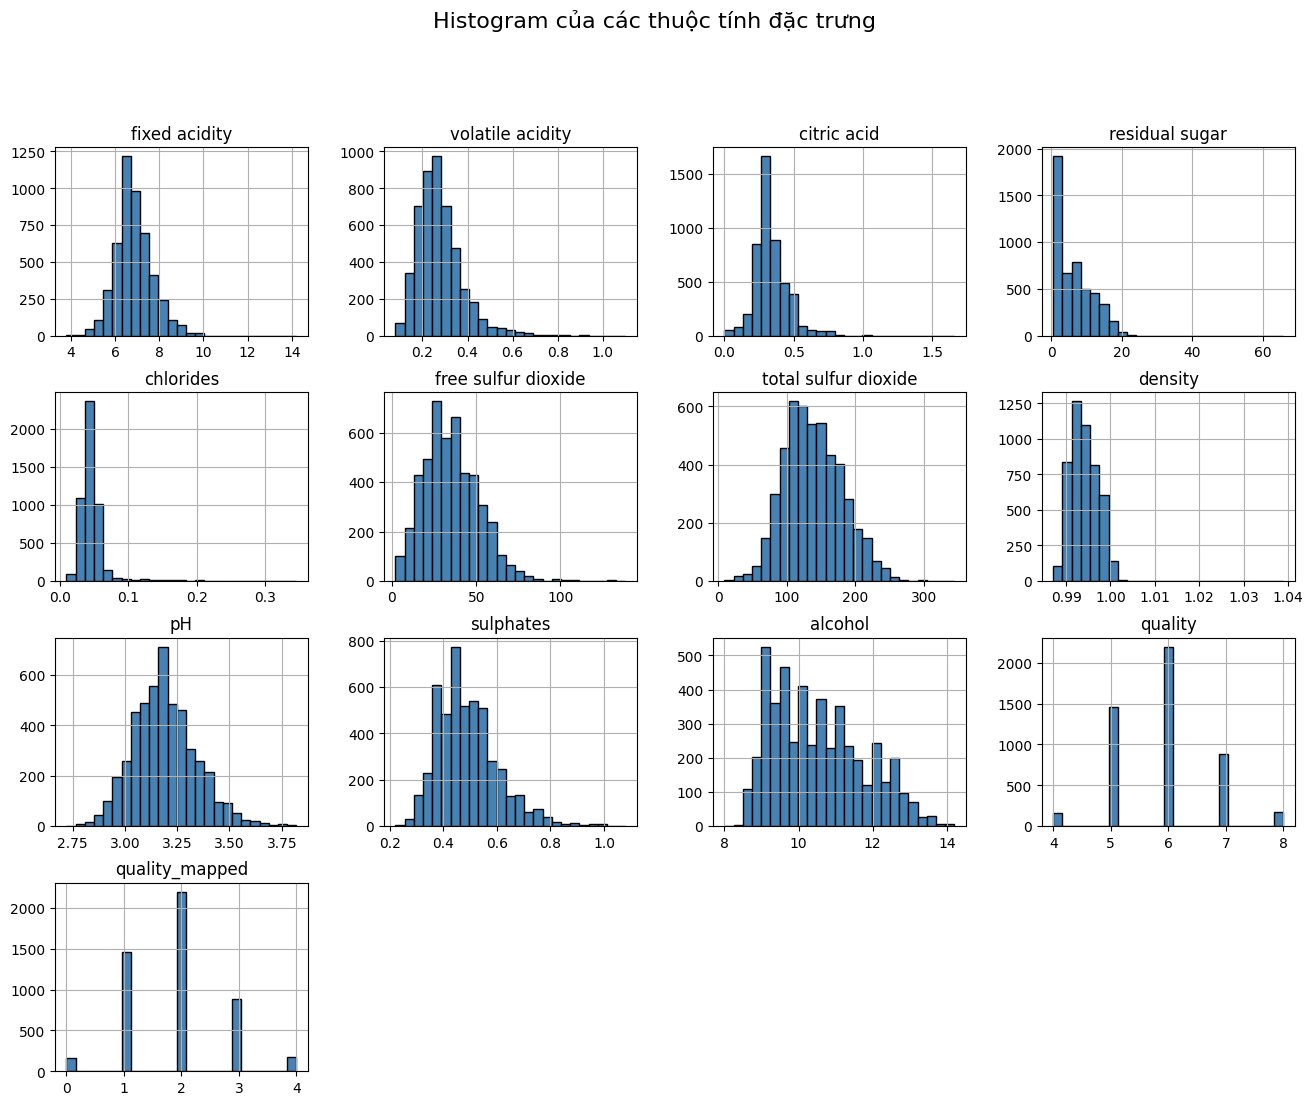

In [ ]:
df.hist(figsize=(16, 12), bins=25, color='steelblue', edgecolor='black')
plt.suptitle('Histogram của các thuộc tính đặc trưng', fontsize=16, y=0.995)
plt.show()

### 5.3 Pairplot - Quan hệ giữa các biến quan trọng

<Figure size 1000x800 with 0 Axes>

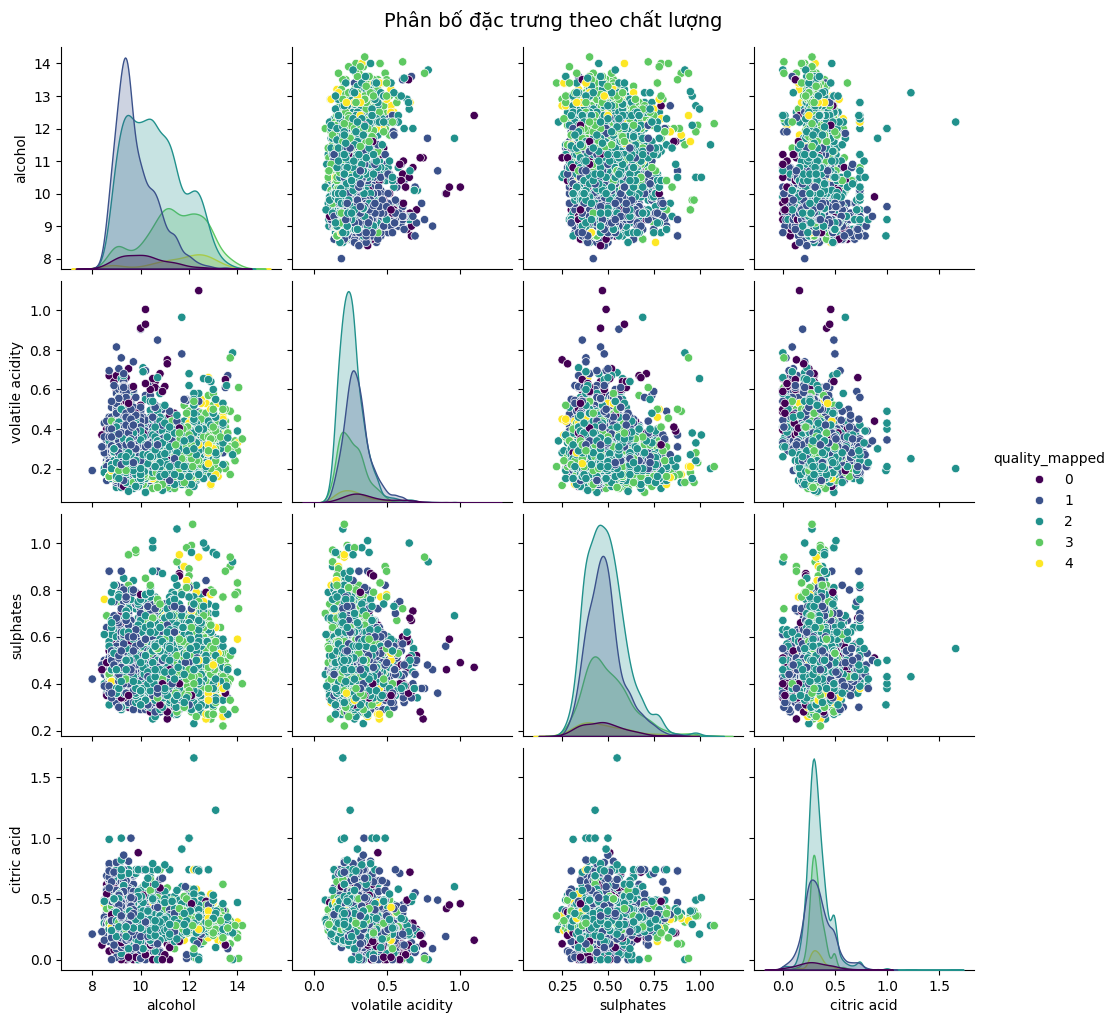

In [ ]:
important_cols = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'quality_mapped']

plt.figure(figsize=(10, 8))
sns.pairplot(df[important_cols], hue='quality_mapped', palette='viridis', diag_kind='kde')
plt.suptitle('Phân bố đặc trưng theo chất lượng', y=1.02, fontsize=14)
plt.show()

## 6. Xây dựng mô hình (Modeling) & Tối ưu hóa (Hyperparameter Tuning)

In [ ]:
best_models = {}
grid_results = {}

### 6.1 Huấn luyện mô hình K-Nearest Neighbors (KNN)

Mô hình KNN được tinh chỉnh thông qua việc tìm kiếm giá trị láng giềng $k$ và trọng số phù hợp.

Trong bài toán dự đoán chất lượng rượu, KNN phân loại một mẫu rượu mới bằng cách xem xét $k$ mẫu rượu đã biết chất lượng gần nó nhất. Nếu phần lớn trong $k$ mẫu này có chất lượng là '2' (Quality 6), thì mẫu rượu mới cũng được dự đoán là chất lượng '2'.

**Không gian tham số (Param Grid):**
*   `n_neighbors`: Thử nghiệm các giá trị số láng giềng gần nhất, ví dụ: `[3, 5, 7, 9, 11, 13, 15]`.
*   `weights`: 'uniform' (tất cả láng giềng có vai trò như nhau) và 'distance' (láng giềng gần hơn có trọng số cao hơn).
*   `metric`: Các độ đo khoảng cách như 'euclidean' hoặc 'manhattan'.

**Kết quả:** Mô hình tự động chọn ra giá trị $k$ tối ưu giúp cân bằng giữa độ chính xác và khả năng tổng quát hóa thông qua quá trình Grid Search Cross-Validation.

In [ ]:
print("=" * 60)
print("Training KNN with GridSearchCV (on Resampled Data)...")
print("=" * 60)

knn_params = {
    'n_neighbors': list(range(3, 16, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(X_train_resampled, y_train_resampled)

best_models['KNN'] = grid_knn.best_estimator_
print(f"\n✓ Best params: {grid_knn.best_params_}")
print(f"✓ Best CV accuracy: {grid_knn.best_score_:.4f}")

Training KNN with GridSearchCV (on Resampled Data)...
Fitting 5 folds for each of 28 candidates, totalling 140 fits

✓ Best params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
✓ Best CV accuracy: 0.8638


### 6.2 Huấn luyện mô hình Decision Tree (Cây Quyết Định)

Cây Quyết Định được tối ưu bằng cách điều chỉnh các tham số cấu trúc của cây để đạt được hiệu suất tốt nhất mà vẫn tránh được hiện tượng quá khớp (overfitting).

**Không gian tham số (Param Grid):**
*   `max_depth`: Độ sâu tối đa của cây (`None` hoặc các giá trị số nguyên như `[10, 20, 30]`). Tham số này giúp kiểm soát độ phức tạp của mô hình, ngăn chặn việc cây trở nên quá sâu và học nhiễu trong dữ liệu.
*   `min_samples_split`: Số lượng mẫu tối thiểu cần có trong một nút để nó có thể được chia tách. Các giá trị thử nghiệm có thể là `[2, 5, 10]`. Tham số này giúp tránh chia tách quá mức các nút nhỏ.
*   `criterion`: Tiêu chí đo lường chất lượng của một lần chia tách. Các lựa chọn phổ biến là 'gini' (Gini impurity) hoặc 'entropy' (information gain).

Kết quả: Mô hình tự động chọn ra các tham số tối ưu (max_depth, min_samples_split, criterion) giúp xây dựng một cây quyết định hiệu quả nhất, cân bằng giữa khả năng học và tránh quá khớp thông qua quá trình Grid Search Cross-Validation.

In [ ]:
print("\n" + "=" * 60)
print("Training Decision Tree with GridSearchCV (on Resampled Data)...")
print("=" * 60)

dt_params = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train_resampled, y_train_resampled)

best_models['Decision Tree'] = grid_dt.best_estimator_
print(f"\n✓ Best params: {grid_dt.best_params_}")
print(f"✓ Best CV accuracy: {grid_dt.best_score_:.4f}")


Training Decision Tree with GridSearchCV (on Resampled Data)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
✓ Best CV accuracy: 0.7669


### 6.3 Huấn luyện mô hình Random Forest (Rừng Ngẫu nhiên)

Random Forest là mô hình tập hợp nên việc tinh chỉnh tập trung vào số lượng cây và độ sâu của từng cây để kiểm soát lỗi quá khớp và tối đa hóa khả năng tổng quát hóa.

**Không gian tham số (Param Grid):**
*   `n_estimators`: Số lượng cây quyết định trong rừng. Thử nghiệm quy mô rừng với `[100, 200]` cây. Số lượng cây càng nhiều thường cho kết quả tốt hơn nhưng tăng thời gian tính toán.
*   `max_depth`: Giới hạn độ sâu tối đa của mỗi cây riêng lẻ (`None` hoặc các giá trị số nguyên như `[5, 10]`). Việc giới hạn độ sâu giúp tránh việc cây học quá chi tiết vào nhiễu và giảm overfitting.
*   `min_samples_leaf`: Số lượng mẫu tối thiểu cần có trong một nút lá. Các giá trị thử nghiệm có thể là `[1, 2, 4]`. Tham số này đảm bảo rằng mỗi nút lá đại diện cho một số lượng mẫu đủ lớn.
*   `max_features`: Số lượng đặc trưng mà mỗi cây con xem xét khi tìm kiếm một chia tách tốt nhất. Các lựa chọn 'sqrt' (căn bậc hai của tổng số đặc trưng) hoặc `None` (sử dụng tất cả đặc trưng).

Kết quả: Mô hình tự động chọn ra các tham số tối ưu (n_estimators, max_depth, min_samples_leaf, max_features) để xây dựng một tập hợp các cây quyết định mạnh mẽ nhất, tối đa hóa hiệu suất dự đoán và giảm thiểu lỗi quá khớp thông qua quá trình Grid Search Cross-Validation.

In [ ]:
print("\n" + "=" * 60)
print("Training Random Forest with GridSearchCV (on Resampled Data)...")
print("=" * 60)

rf_params = {
    'n_estimators': [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_resampled, y_train_resampled)

best_models['Random Forest'] = grid_rf.best_estimator_
print(f"\n✓ Best params: {grid_rf.best_params_}")
print(f"✓ Best CV accuracy: {grid_rf.best_score_:.4f}")


Training Random Forest with GridSearchCV (on Resampled Data)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✓ Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
✓ Best CV accuracy: 0.8643


### 6.4 Huấn luyện mô hình Support Vector Machine (SVM)

SVM là một mô hình phân loại mạnh mẽ, tìm kiếm siêu phẳng (hyperplane) tối ưu để phân tách các lớp dữ liệu. Việc tinh chỉnh các tham số giúp SVM đạt được hiệu suất tốt nhất.

**Không gian tham số (Param Grid):**
*   `C`: Tham số điều chỉnh sự đánh đổi giữa việc phân loại đúng các điểm dữ liệu huấn luyện và việc có một biên phân tách rộng. Các giá trị phổ biến là `[0.1, 1, 10]`. Giá trị C nhỏ hơn tạo ra biên phân tách lớn hơn nhưng có thể chấp nhận nhiều lỗi phân loại hơn. Ngược lại, C lớn hơn ưu tiên phân loại đúng các điểm huấn luyện hơn, có thể dẫn đến biên phân tách hẹp hơn.
*   `kernel`: Loại hàm kernel được sử dụng để biến đổi dữ liệu thành không gian có thứ nguyên cao hơn, cho phép tìm thấy một siêu phẳng phân tách tuyến tính. Các lựa chọn phổ biến là 'linear' (tuyến tính), 'rbf' (hàm cơ sở xuyên tâm - Radial Basis Function) và 'poly' (đa thức).
*   `gamma`: Tham số kernel cho 'rbf', 'poly' và 'sigmoid'. Nó định nghĩa mức độ ảnh hưởng của một mẫu huấn luyện duy nhất. Các giá trị thường được thử nghiệm là `[0.1, 1, 10]`. Giá trị gamma nhỏ hơn có nghĩa là biên phân tách có phạm vi lớn, trong khi giá trị gamma lớn hơn làm cho biên phân tách có phạm vi nhỏ hơn (ảnh hưởng chỉ bởi các điểm gần).

**Kết quả:** Mô hình tự động chọn ra các tham số tối ưu (C, kernel, gamma) giúp SVM xây dựng một siêu phẳng phân tách hiệu quả nhất, tối đa hóa hiệu suất dự đoán và giảm thiểu lỗi quá khớp thông qua quá trình Grid Search Cross-Validation.

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

print("\n" + "=" * 60)
print("Training SVM with GridSearchCV (on Resampled Data)...")
print("=" * 60)

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(random_state=42, probability=True),
    svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_resampled, y_train_resampled)

best_models['SVM'] = grid_svm.best_estimator_
print(f"\n✓ Best params: {grid_svm.best_params_}")
print(f"✓ Best CV accuracy: {grid_svm.best_score_:.4f}")


Training SVM with GridSearchCV (on Resampled Data)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✓ Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
✓ Best CV accuracy: 0.8035


### 6.5 Huấn luyện mô hình XGBoost

XGBoost (eXtreme Gradient Boosting) là một thuật toán cây tăng cường được thiết kế để tối ưu hóa hiệu suất và tốc độ. Nó rất hiệu quả trong việc giải quyết các bài toán phân loại và hồi quy.

**Không gian tham số (Param Grid):**
*   `n_estimators`: Số lượng cây tăng cường (boosting rounds) hoặc số cây mà mô hình xây dựng. Các giá trị như `[100, 200]` thường được thử nghiệm. Số lượng cây càng nhiều có thể cải thiện hiệu suất nhưng cũng tăng thời gian huấn luyện và nguy cơ overfitting.
*   `max_depth`: Độ sâu tối đa của mỗi cây trong rừng. `[3, 5, 7]` là các giá trị phổ biến. Kiểm soát độ sâu giúp điều chỉnh độ phức tạp của từng cây và giảm overfitting.
*   `learning_rate`: Tốc độ học (hay còn gọi là bước nhảy) mà mỗi cây đóng góp vào tổng mô hình. `[0.01, 0.1, 0.2]` là các giá trị thường dùng. Tốc độ học nhỏ hơn yêu cầu nhiều cây hơn nhưng có thể dẫn đến mô hình mạnh mẽ và tổng quát hơn.
*   `subsample`: Tỷ lệ mẫu con (subsample ratio) của các phiên bản được chọn ngẫu nhiên trước khi xây dựng cây. Các giá trị như `[0.7, 0.8, 0.9]` giúp giảm variance và ngăn chặn overfitting.
*   `colsample_bytree`: Tỷ lệ mẫu con của các đặc trưng (features) được chọn ngẫu nhiên cho mỗi cây. `[0.7, 0.8, 0.9]` giúp ngăn chặn một đặc trưng duy nhất chiếm ưu thế trong quá trình xây dựng cây.

**Kết quả:** Mô hình tự động chọn ra các tham số tối ưu giúp XGBoost xây dựng một mô hình mạnh mẽ và chính xác nhất, tối đa hóa hiệu suất dự đoán và giảm thiểu lỗi quá khớp thông qua quá trình Grid Search Cross-Validation.

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

print("\n" + "=" * 60)
print("Training XGBoost with GridSearchCV (on Resampled Data)...")
print("=" * 60)

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

grid_xgb = GridSearchCV(
    xgb.XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', use_label_encoder=False, random_state=42),
    xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_resampled, y_train_resampled)

best_models['XGBoost'] = grid_xgb.best_estimator_
print(f"\n✓ Best params: {grid_xgb.best_params_}")
print(f"✓ Best CV accuracy: {grid_xgb.best_score_:.4f}")


Training XGBoost with GridSearchCV (on Resampled Data)...
Fitting 5 folds for each of 162 candidates, totalling 810 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:59:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✓ Best params: {'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7}
✓ Best CV accuracy: 0.8628


## 7. Đánh giá mô hình (Model Evaluation)
Đánh giá toàn diện các mô hình trên tập Test.


ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST THỰC TẾ (MULTI-CLASS) KHI CHƯA SMOTE


,Model,Test Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,KNN,0.5569,0.5959,0.5569,0.5686
1,Decision Tree,0.5733,0.5887,0.5733,0.5787
2,Random Forest,0.6410,0.6459,0.6410,0.6429
3,SVM,0.5138,0.5471,0.5138,0.5209
4,XGBoost,0.6349,0.6336,0.6349,0.6319



CONFUSION MATRIX - SO SÁNH CÁC MÔ HÌNH (MULTI-CLASS)


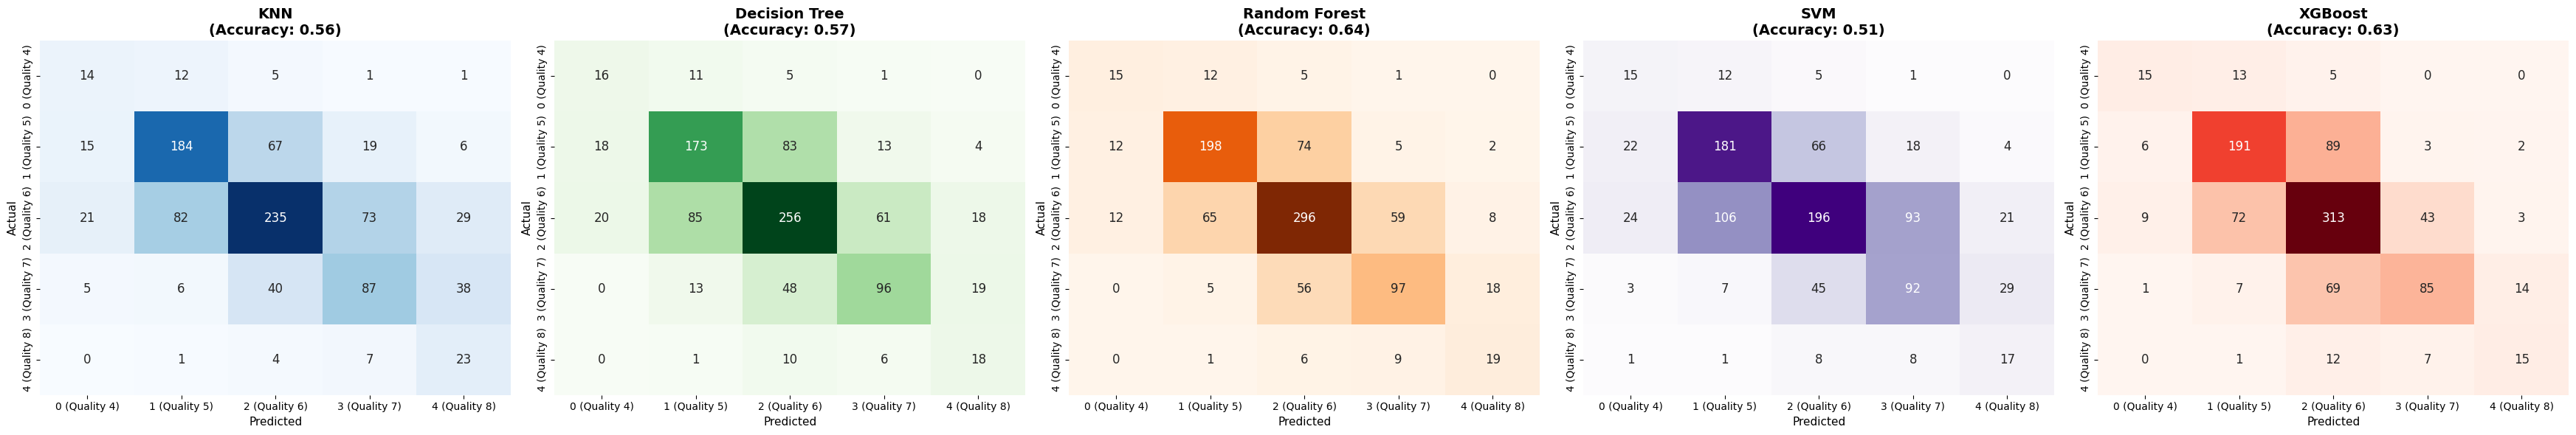


CHI TIẾT BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)

Model: KNN
               precision    recall  f1-score   support

0 (Quality 4)       0.25      0.42      0.32        33
1 (Quality 5)       0.65      0.63      0.64       291
2 (Quality 6)       0.67      0.53      0.59       440
3 (Quality 7)       0.47      0.49      0.48       176
4 (Quality 8)       0.24      0.66      0.35        35

     accuracy                           0.56       975
    macro avg       0.45      0.55      0.48       975
 weighted avg       0.60      0.56      0.57       975


Model: Decision Tree
               precision    recall  f1-score   support

0 (Quality 4)       0.30      0.48      0.37        33
1 (Quality 5)       0.61      0.59      0.60       291
2 (Quality 6)       0.64      0.58      0.61       440
3 (Quality 7)       0.54      0.55      0.54       176
4 (Quality 8)       0.31      0.51      0.38        35

     accuracy                           0.57       975
    macro avg       0.48     

In [ ]:
print("\n" + "=" * 80)
print("ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST THỰC TẾ (MULTI-CLASS) KHI CHƯA SMOTE")
print("=" * 80)

results = []

target_names_mapped = ['0 (Quality 4)', '1 (Quality 5)', '2 (Quality 6)', '3 (Quality 7)', '4 (Quality 8)']

for name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        'Model': name,
        'Test Accuracy': f"{acc:.4f}",
        'Precision (Weighted)': f"{prec:.4f}",
        'Recall (Weighted)': f"{rec:.4f}",
        'F1-Score (Weighted)': f"{f1:.4f}",
    })

results_df = pd.DataFrame(results)
display(results_df)

print("\n" + "=" * 80)
print("CONFUSION MATRIX - SO SÁNH CÁC MÔ HÌNH (MULTI-CLASS)")
print("=" * 80)

fig, axes = plt.subplots(1, len(best_models), figsize=(len(best_models) * 7, 6))
colors = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds']
labels = target_names_mapped

for idx, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap=colors[idx], ax=axes[idx],
        xticklabels=labels, yticklabels=labels,
        cbar=False, annot_kws={"size": 12}
    )

    axes[idx].set_title(f'{name}\n(Accuracy: {accuracy_score(y_test, y_pred):.2f})', fontsize=14, weight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("CHI TIẾT BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)")
print("=" * 80)
for name, model in best_models.items():
    print(f"\nModel: {name}")
    y_pred = model.predict(X_test_scaled)
    print(classification_report(y_test, y_pred, target_names=target_names_mapped))

## 8. Phân tích Feature Importance (Random Forest)
Xem yếu tố nào ảnh hưởng quan trọng nhất đến chất lượng rượu.


TOP 5 ĐẶC TRƯNG QUAN TRỌNG NHẤT (FEATURE IMPORTANCE)


,Feature,Importance,Cumulative %
10,alcohol,0.126263,12.626320
5,free sulfur dioxide,0.113538,23.980120
1,volatile acidity,0.104751,34.455250
7,density,0.089005,43.355758
6,total sulfur dioxide,0.088356,52.191315


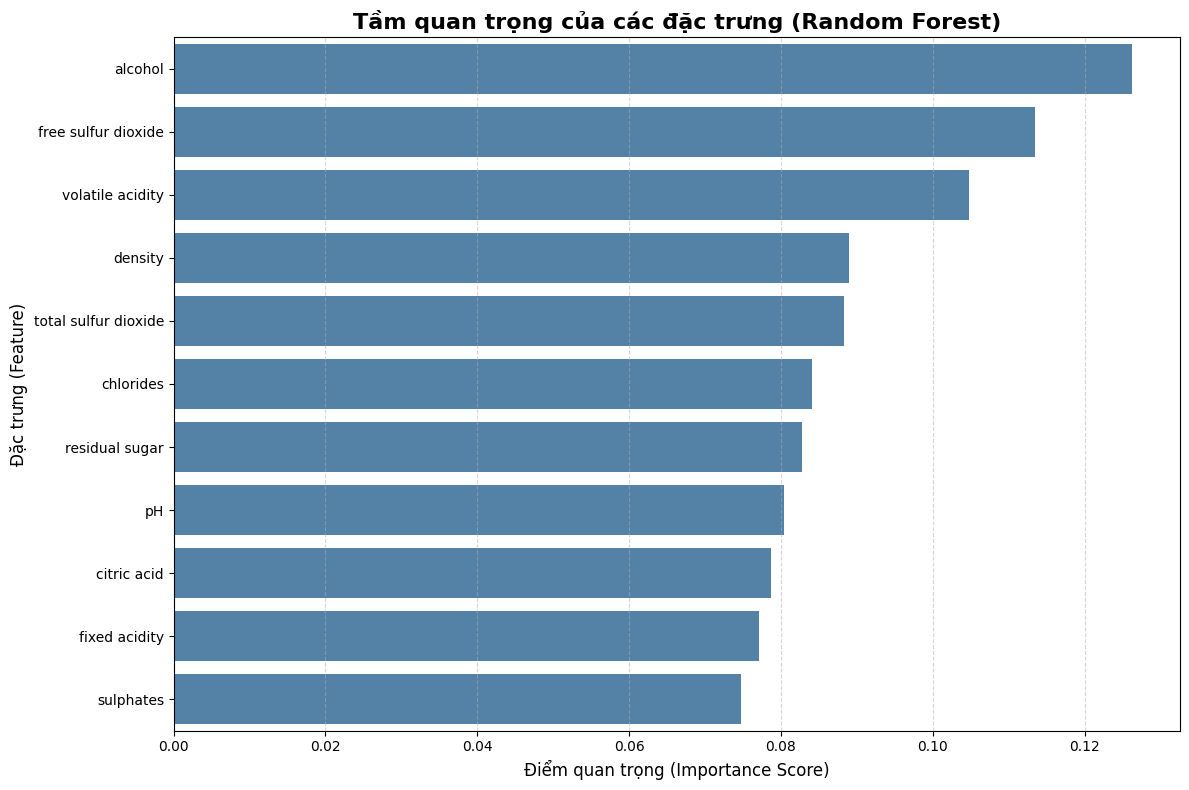

In [ ]:
feature_names = X_train.columns.tolist()
rf_model = best_models['Random Forest']
importances = rf_model.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n" + "=" * 60)
print("TOP 5 ĐẶC TRƯNG QUAN TRỌNG NHẤT (FEATURE IMPORTANCE)")
print("=" * 60)
feature_imp_df['Cumulative %'] = feature_imp_df['Importance'].cumsum() * 100
display(feature_imp_df.head(5))

plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_imp_df,
    color='steelblue'
)

plt.title('Tầm quan trọng của các đặc trưng (Random Forest)', fontsize=16, weight='bold')
plt.xlabel('Điểm quan trọng (Importance Score)', fontsize=12)
plt.ylabel('Đặc trưng (Feature)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 9. Đường cong ROC (One-vs-Rest) cho bài toán đa lớp

Điều này giúp đánh giá khả năng của mô hình trong việc phân biệt từng lớp cụ thể.


ĐƯỜNG CONG ROC (ONE-VS-REST) CỦA MÔ HÌNH RANDOM FOREST


/tmp/ipykernel_1261/2993251769.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('jet', n_classes)


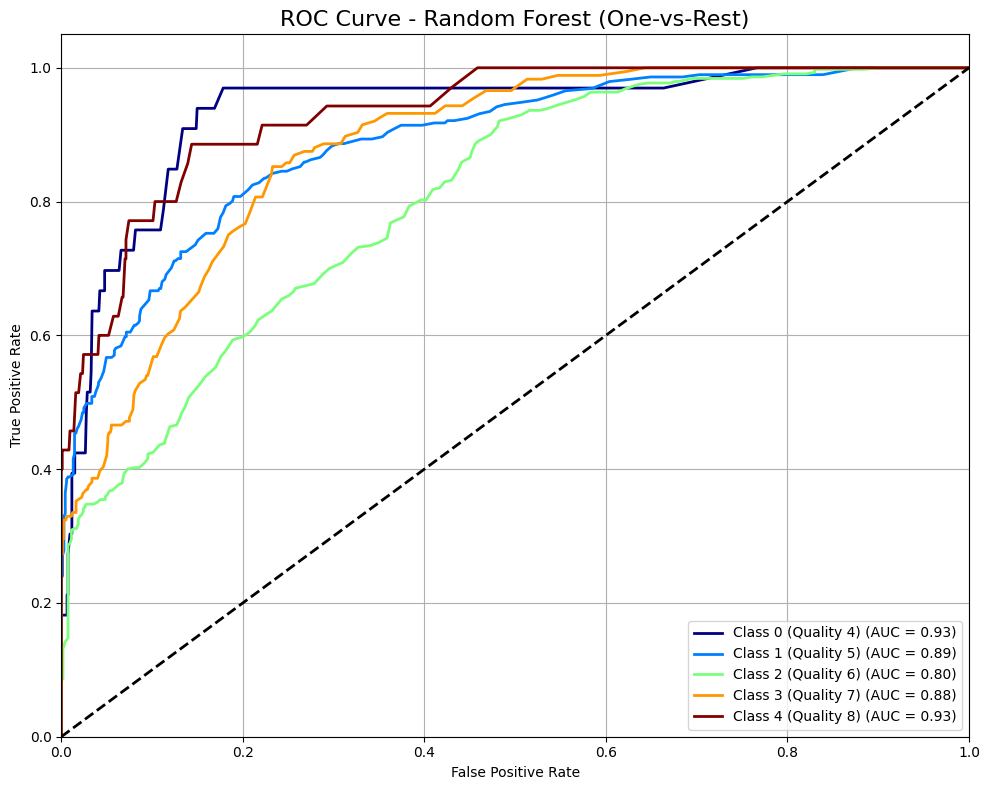

In [ ]:
print("\n" + "=" * 80)
print("ĐƯỜNG CONG ROC (ONE-VS-REST) CỦA MÔ HÌNH RANDOM FOREST")
print("=" * 80)

label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)
n_classes = len(label_binarizer.classes_)

best_model_name = 'Random Forest'
model = best_models[best_model_name]

fig, ax = plt.subplots(figsize=(10, 8))
y_proba = model.predict_proba(X_test_scaled)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
colors = plt.cm.get_cmap('jet', n_classes)
for i in range(n_classes):
    ax.plot(fpr[i], tpr[i], color=colors(i), lw=2,
            label=f'Class {target_names_mapped[i]} (AUC = {roc_auc[i]:0.2f})')
ax.plot([0, 1], [0, 1], 'k--', lw=2)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curve - {best_model_name} (One-vs-Rest)', fontsize=16)
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()